<font color="purple" size=5><center><b>Task-3 Handwritten-Character-Recognization-Model </b></center></font>

<font color="grey" size=5>**1) Importing Library's**</font>

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path
import numpy as np
import joblib
import os
# 1. LOAD DATASET
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

Loading MNIST dataset...


<font color="grey" size=5>**2) PreProcessing**</font>

In [39]:
# 2. PREPROCESSING
# Normalize pixel values to be between 0 and 1
X_train, X_test = X_train / 255.0, X_test / 255.0

# Reshape data to include the channel dimension (28x28x1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

<font color="grey" size=5>**3) Model Training**</font>

In [40]:
# 3. BUILD CNN MODEL (Warning-free version)
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # Prevents overfitting
    layers.Dense(10, activation='softmax') # 10 output classes (0-9)
])
# 4. COMPILE MODEL
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

<font color="grey" size=5>**4) Model Testing**</font>

In [41]:
# 5. TRAIN MODEL
print("\nStarting training...")
history = model.fit(X_train, y_train, epochs=5, 
                    validation_data=(X_test, y_test), 
                    batch_size=64)

# 6. TEST & EVALUATE
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")



Starting training...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.9314 - loss: 0.2264 - val_accuracy: 0.9820 - val_loss: 0.0585
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9764 - loss: 0.0756 - val_accuracy: 0.9871 - val_loss: 0.0414
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9841 - loss: 0.0528 - val_accuracy: 0.9891 - val_loss: 0.0320
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9868 - loss: 0.0420 - val_accuracy: 0.9872 - val_loss: 0.0366
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.9893 - loss: 0.0338 - val_accuracy: 0.9902 - val_loss: 0.0282
313/313 - 3s - 8ms/step - accuracy: 0.9902 - loss: 0.0282

Test Accuracy: 99.02%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step


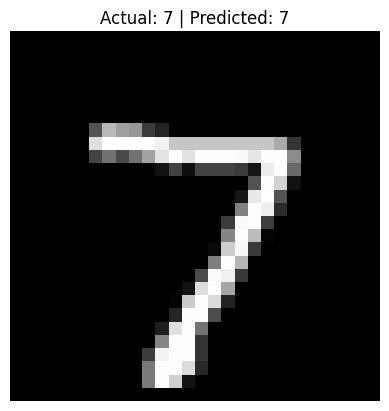

In [43]:
# 7. PREDICT & VISUALIZE
def plot_prediction(index):
    img = X_test[index].reshape(28, 28)
    prediction = model.predict(X_test[index:index+1])
    predicted_digit = np.argmax(prediction)
    
    plt.imshow(img, cmap='gray')
    plt.title(f"Actual: {y_test[index]} | Predicted: {predicted_digit}")
    plt.axis('off')
    plt.show()

# Predict the first image in the test set
plot_prediction(0)

<font color="grey" size=5>**5) Vizualization**</font>

<font color="grey" size=5>**a) CNN Line Chart**</font>

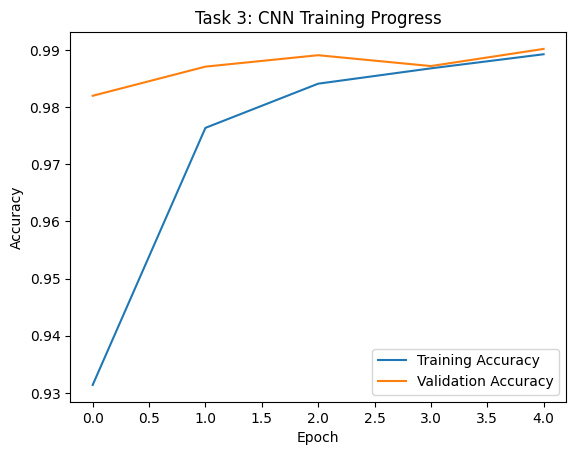

In [44]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Task 3: CNN Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

<font color="grey" size=5>**b) Bar Chart**</font>

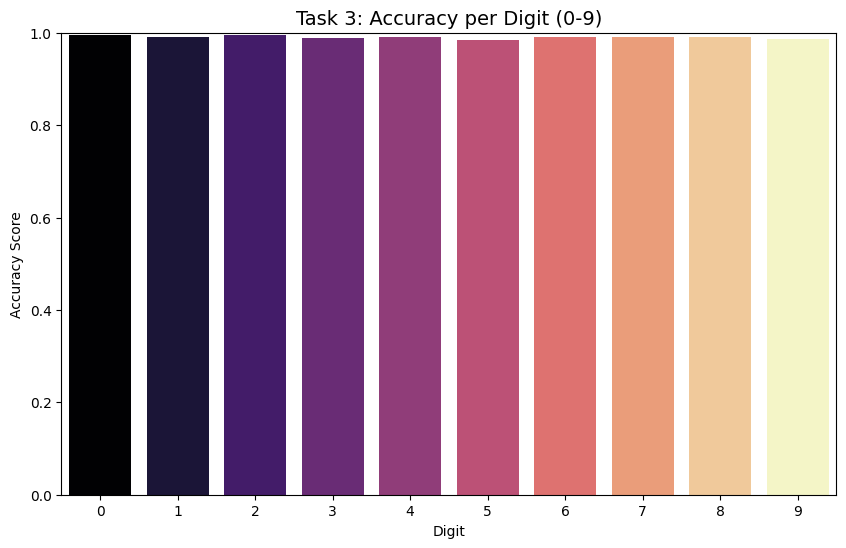

In [45]:
# --- 1. BAR CHART: Class-wise Accuracy ---
cm = confusion_matrix(y_test, y_pred)
# Calculate accuracy for each digit (diagonal / sum of row)
class_accuracies = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(range(10)), y=class_accuracies, hue=list(range(10)), palette='magma', legend=False)
plt.title('Task 3: Accuracy per Digit (0-9)', fontsize=14)
plt.xlabel('Digit')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.0)
plt.show()

<font color="grey" size=5>**c) Line Chart**</font>

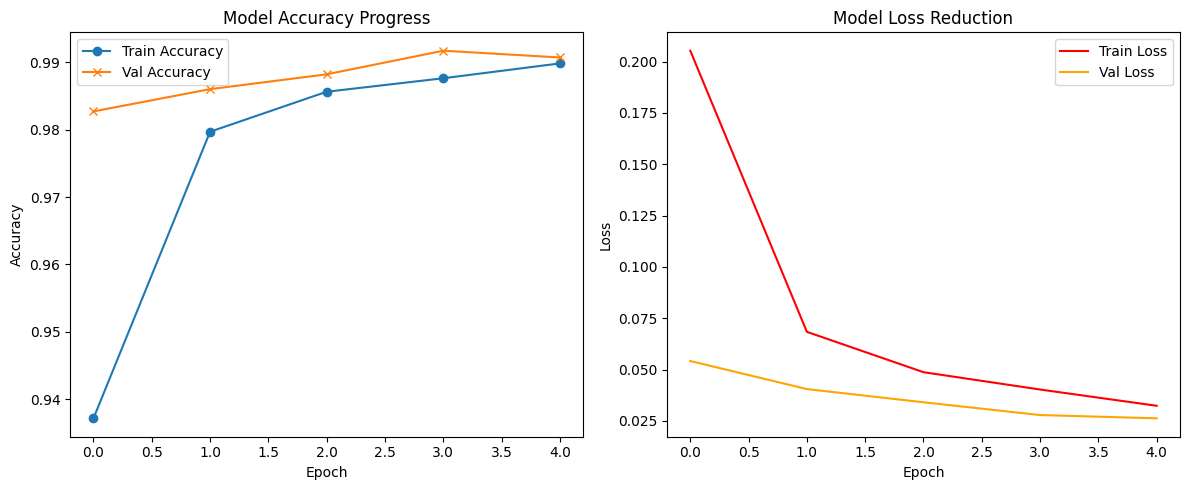

In [20]:
# --- 2. LINE CHART: Training & Validation History ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='x')
plt.title('Model Accuracy Progress')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss Reduction')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
    
plt.tight_layout()
plt.show()


<font color="grey" size=5>**d) Heat Map**</font>

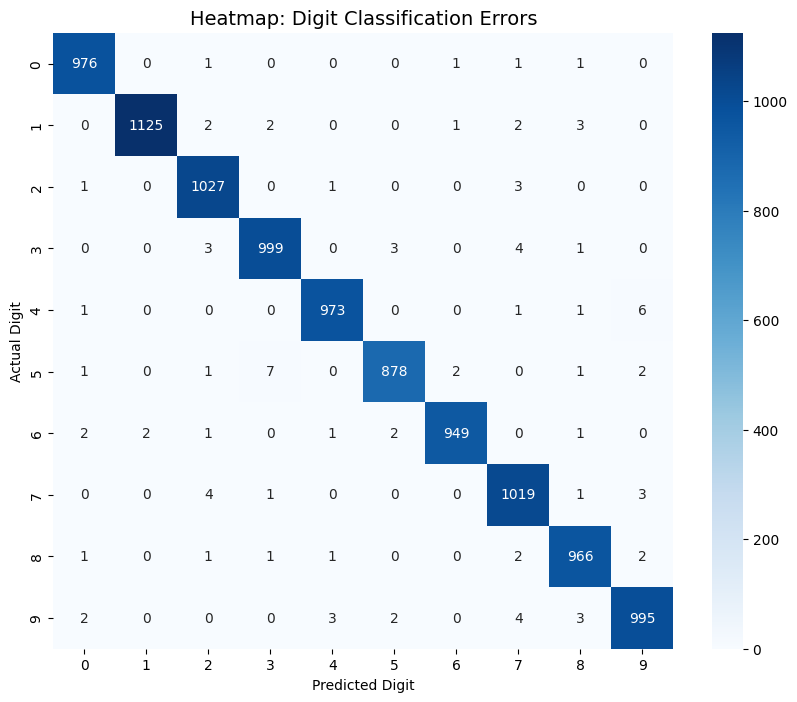

In [32]:
# --- 3. HEATMAP: Error Analysis (Confusion Matrix) ---
y_pred = np.argmax(y_pred_probs, axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Heatmap: Digit Classification Errors', fontsize=14)
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.show()


<font color="grey" size=5>**e) Pie Chart**</font>

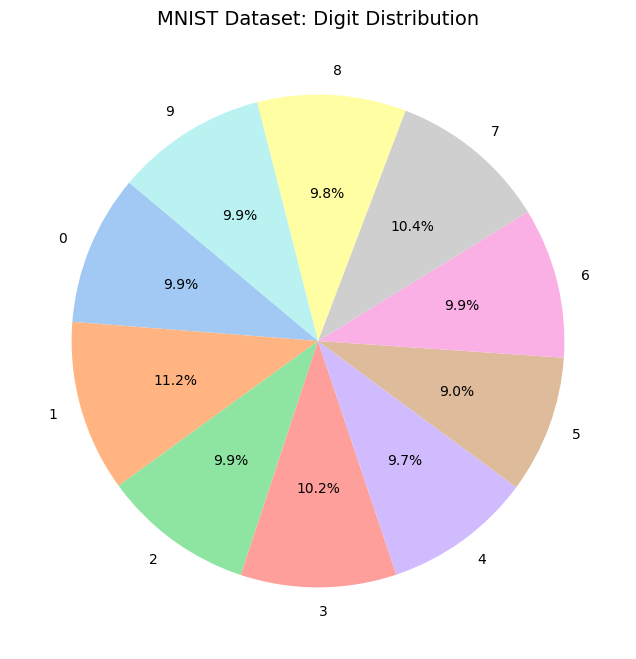

In [17]:
# --- 4. PIE CHART: Dataset Composition ---
# def plot_dataset_pie(y_train):
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=unique, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('MNIST Dataset: Digit Distribution', fontsize=14)
plt.show()

<font color="grey" size=5>**6) Deployment**</font>

In [46]:
deployment_package = {
    'model_architecture': model.to_json(),
    'model_weights': model.get_weights(),
    'metadata': {
        'input_shape': (28, 28, 1),
        'classes': 10,
        'normalization': 'div_255'
    }
}
print(f"\nDeploying the best model ({model})...")   
output_path = Path("pkl")
output_path.mkdir(parents=True, exist_ok=True)
joblib.dump(deployment_package, output_path / 'mnist_cnn_deployment.pkl')
print("Deployment complete: Model saved as 'mnist_cnn_deployment.pkl'")


Deploying the best model (<Sequential name=sequential_5, built=True>)...
Deployment complete: Model saved as 'mnist_cnn_deployment.pkl'
